# Logistic Regression trên ViCTSD

So sánh cùng một kiến trúc khi train trên nhãn gốc và nhãn AI re-annotated.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError('Run this notebook from the project root or notebooks/ directory.')

sys.path.insert(0, str(PROJECT_ROOT))
root = PROJECT_ROOT
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/abc/Documents/multi-agent-annotation


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.experiment_utils import (
    compare_predictions,
    compare_prediction_disagreements,
    evaluate_predictions,
    load_victsd_splits,
    make_text_xy,
    train_predict_pair,
)

sns.set_theme(style='whitegrid')

In [3]:
splits = load_victsd_splits(root / 'data')

X_train_orig, y_train_orig = make_text_xy(splits['train_orig'])
X_train_new, y_train_new = make_text_xy(splits['train_new'])
X_test, y_test = make_text_xy(splits['test'])

Loaded splits: train_orig=7000, train_new=7000, valid_orig=2000, valid_new=2000, test=1000


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

MODEL_NAME = 'Logistic Regression'

def build_model():
    return Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ])

Training Logistic Regression on original labels...


--- Logistic Regression (Original labels) ---
Accuracy=0.8100 | F1 macro=0.8019 | Precision macro=0.7972 | Recall macro=0.8154
                  precision    recall  f1-score   support

Non-constructive       0.89      0.80      0.84       636
    Constructive       0.70      0.84      0.76       364

        accuracy                           0.81      1000
       macro avg       0.80      0.82      0.80      1000
    weighted avg       0.82      0.81      0.81      1000


Training Logistic Regression on AI re-annotated labels...


--- Logistic Regression (AI re-annotated labels) ---
Accuracy=0.7570 | F1 macro=0.7275 | Precision macro=0.7403 | Recall macro=0.7208
                  precision    recall  f1-score   support

Non-constructive       0.78      0.85      0.82       636
    Constructive       0.70      0.59      0.64       364

        accuracy                           0.76      1000
       macro avg       0.74      0.72      0.73      1000
    weighted avg       0.75      0.76      0.75      1000


Compare result: Logistic Regression


,Metric,Original labels,AI re-annotated labels,Delta
0,Accuracy,0.8100,0.7570,-0.0530
1,F1 weighted,0.8128,0.7519,-0.0609
2,F1 macro,0.8019,0.7275,-0.0744
3,Precision macro,0.7972,0.7403,-0.0569
4,Recall macro,0.8154,0.7208,-0.0945


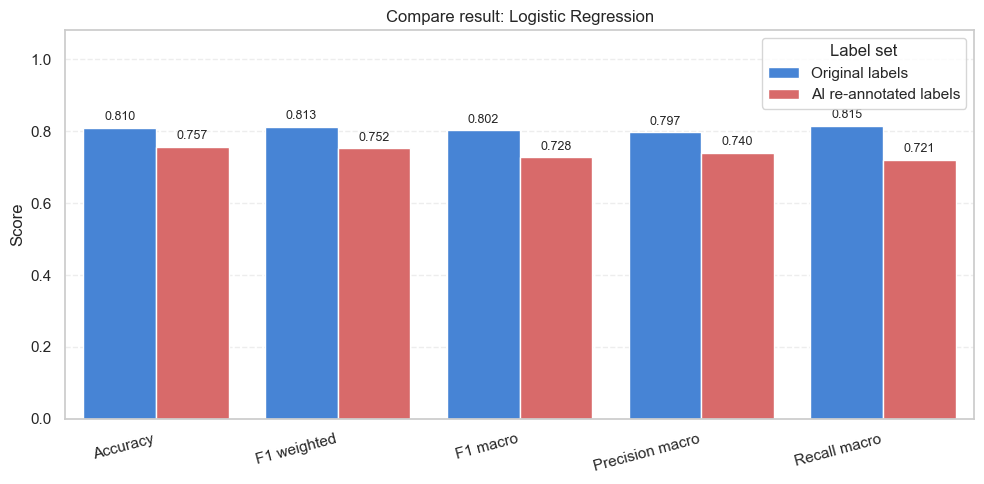

In [5]:
lr_orig, lr_new, y_pred_orig, y_pred_new, comparison = train_predict_pair(
    build_model=build_model,
    X_train_original=X_train_orig,
    y_train_original=y_train_orig,
    X_train_reannotated=X_train_new,
    y_train_reannotated=y_train_new,
    X_test=X_test,
    y_test=y_test,
    model_name=MODEL_NAME,
)

In [6]:
diff_df = compare_prediction_disagreements(X_test, y_test, y_pred_orig, y_pred_new)
diff_df.head(10)

Prediction disagreements: 191 / 1000


,text,true_label,pred_original,pred_reannotated
0,đời ta ba mươi đời nó. mua chiếc xe cũng chỉ p...,0,1,0
1,"tước bằng lái vĩnh viễn đi. chạy lếu láo thật,...",1,1,0
2,ko có từ nào hình dung về 2 đứa này đc! ng ta ...,0,1,0
3,cảm giác của nam thanh niên khi bị chúng đe dọ...,1,1,0
4,thực ra bây giờ mọi người chụp ảnh rất nhiều n...,0,1,0
5,"phải sống chung với dịch thôi, đóng đến bao gi...",0,1,0
6,lịch công việc và đi lại của ông dầy đặc như v...,1,1,0
7,murray cố nhưng cũng k thể thi đấu đỉnh cao đc...,0,1,0
8,"ông này cực kỳ có duyên với cup. ronaldo, kaka...",1,1,0
9,"chào khán giả, thật ra mình cũng xem phim anh ...",1,1,0
